In [1]:
import  numpy as  np  
import  pandas as pd  
df  = pd.read_csv('C:\\Users\\Admin\\ml  batch  -p\\test\\cars - cars.csv')
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [2]:
import  matplotlib.pyplot as  plt 
import  seaborn as sns

In [3]:
num= df.select_dtypes(include=['number']).columns.to_list()
num

['year', 'selling_price', 'km_driven']

<Axes: xlabel='year'>

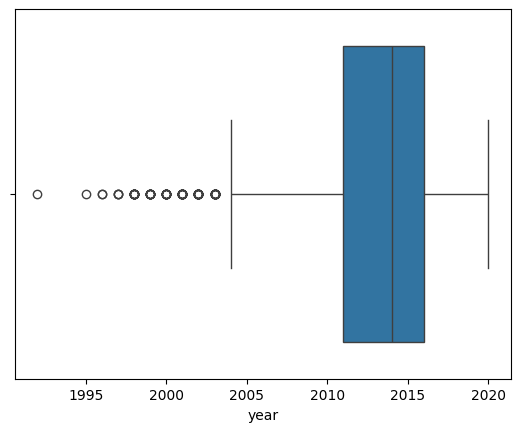

In [4]:
sns.boxplot(x=df['year'])

<Axes: xlabel='selling_price'>

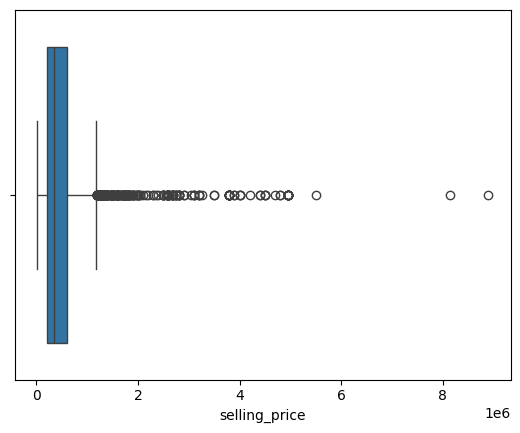

In [5]:
sns.boxplot(x=df['selling_price'])

<Axes: xlabel='km_driven'>

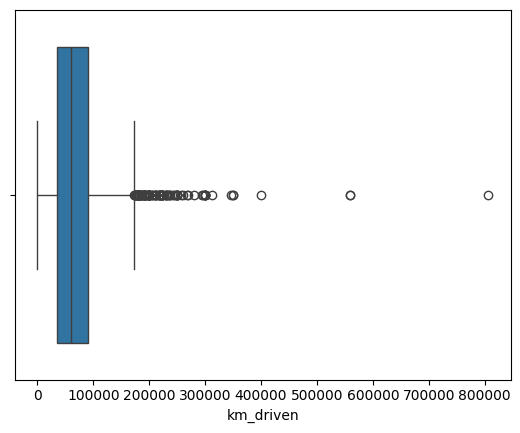

In [6]:
sns.boxplot(x=df['km_driven'])

In [7]:
# applying capping 

In [8]:
new_df = df.copy()

In [9]:
percentile_25_year = new_df['year'].quantile(0.25)
percentile_75_year = new_df['year'].quantile(0.75)

percentile_25_selling_price = new_df['selling_price'].quantile(0.25)
percentile_75_selling_price = new_df['selling_price'].quantile(0.75)

percentile_25_km_driven = new_df['km_driven'].quantile(0.25)
percentile_75_km_driven = new_df['km_driven'].quantile(0.75)

In [10]:
IQR_Y =  percentile_75_year - percentile_25_year
IQR_S =  percentile_75_selling_price - percentile_25_selling_price 
IQR_K =  percentile_75_km_driven  - percentile_25_km_driven

In [11]:
upper_limit_Y  = percentile_75_year +1.5 * IQR_Y
upper_limit_S =  percentile_75_selling_price + 1.5 * IQR_S 
upper_limit_K =   percentile_75_km_driven + 1.5 * IQR_K

In [12]:
lower_limit_Y = percentile_25_year - 1.5 * IQR_Y
lower_limit_S = percentile_25_selling_price - 1.5 * IQR_S
lower_limit_K = percentile_25_km_driven - 1.5 * IQR_K

In [13]:
new_df['year'] = np.where(new_df['year']>upper_limit_Y,upper_limit_Y,
                          np.where(new_df['year']<lower_limit_Y,lower_limit_Y,new_df['year']))

In [14]:
new_df['selling_price']  = np.where(new_df['selling_price']>upper_limit_S,upper_limit_S,
                            np.where(new_df['selling_price']<lower_limit_S,lower_limit_S,new_df['selling_price']))

In [15]:
new_df['km_driven'] =  np.where(new_df['km_driven']>upper_limit_K,upper_limit_K,
                                np.where(new_df['km_driven']<lower_limit_K,lower_limit_K,new_df['km_driven']))


<Axes: xlabel='year'>

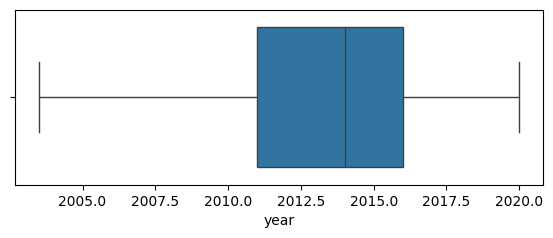

In [16]:
plt.figure(figsize = (15,5))
plt.subplot(222)
sns.boxplot(x=new_df['year'])

<Axes: xlabel='selling_price'>

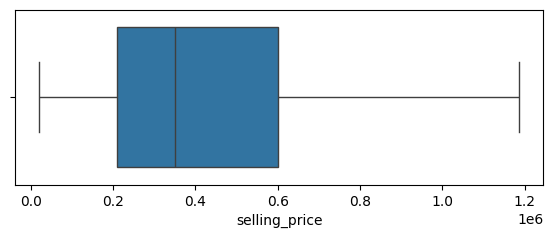

In [17]:
plt.figure(figsize = (15,5))
plt.subplot(221)
sns.boxplot(x=new_df['selling_price'])

<Axes: xlabel='km_driven'>

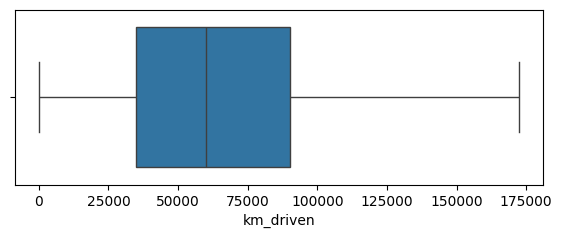

In [18]:
plt.figure(figsize = (15,5))
plt.subplot(223)
sns.boxplot(x=new_df['km_driven'])

In [19]:
# so  we  remove  all  outliers 

In [20]:
# now we apply standardscaler  on  new_df
new_df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [21]:
x = new_df.drop(columns=['name','selling_price'])

In [22]:
y=new_df['selling_price']

In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [24]:
cat = x_train.select_dtypes(include=['object','category']).columns.to_list()
num  = x_train.select_dtypes(include=['number']).columns.to_list()


In [25]:
from sklearn.preprocessing import  OneHotEncoder
ohe =  OneHotEncoder(drop='first',sparse_output=False,dtype=np.int32)

In [26]:
x_train_enco_cat = ohe.fit_transform(x_train[cat])
x_test_enco_cat = ohe.transform(x_test[cat])    # sir convert all  categorical  into  numerical or encoded 

x_train_cat =  pd.DataFrame(x_train_enco_cat,columns=ohe.get_feature_names_out(cat))
x_test_cat = pd.DataFrame(x_test_enco_cat,columns=ohe.get_feature_names_out(cat))

In [27]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train[num]) 
x_test_sc = sc.transform(x_test[num])

x_train_new  = pd.DataFrame(x_train_sc,columns=x_train[num].columns)
x_test_new  = pd.DataFrame(x_test_sc,columns=x_test[num].columns)

In [28]:
x_train_cat_num = pd.concat([x_train_new,x_train_cat],axis=1)
np.round(x_train_cat_num.describe(),2)   # sir we  not scaled categorical  columns  ,and  we not encoded numrical columns 

,year,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
count,3472.00,3472.00,3472.0,3472.00,3472.00,3472.00,3472.00,3472.00,3472.0,3472.00,3472.00,3472.00,3472.00
mean,-0.00,0.00,0.5,0.00,0.01,0.48,0.75,0.02,0.9,0.02,0.25,0.00,0.07
std,1.00,1.00,0.5,0.02,0.08,0.50,0.44,0.15,0.3,0.13,0.44,0.06,0.25
min,-2.44,-1.63,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
25%,-0.55,-0.75,0.0,0.00,0.00,0.00,0.00,0.00,1.0,0.00,0.00,0.00,0.00
50%,0.20,-0.13,1.0,0.00,0.00,0.00,1.00,0.00,1.0,0.00,0.00,0.00,0.00
75%,0.70,0.62,1.0,0.00,0.00,1.00,1.00,0.00,1.0,0.00,1.00,0.00,0.00
max,1.71,2.68,1.0,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00


In [29]:
x_test_cat_num =  pd.concat([x_test_new,x_test_cat],axis=1)
x_test_cat_num

,year,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,1.206592,-1.252890,0,0,0,1,1,0,0,0,0,0,0
1,-0.301612,1.369518,1,0,0,0,1,0,1,0,1,0,0
2,0.452490,-0.378754,1,0,0,0,1,0,1,0,0,0,0
3,-2.438234,0.120752,0,0,0,1,1,0,1,0,0,0,1
4,-0.301612,-0.300781,0,0,0,1,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,0.955225,-0.753384,0,0,0,1,1,0,1,0,0,0,0
864,0.703858,-0.878260,0,0,0,1,1,0,1,0,1,0,0
865,-1.558449,0.270604,0,0,0,1,0,0,1,0,0,0,1
866,-0.301612,0.620259,0,0,0,1,1,0,1,0,1,0,0


In [30]:

# second task  :- work on In credit scoring data 


In [51]:
import  numpy as np 
import  pandas  as  pd  
df =  pd.read_csv('C:\\Users\\Admin\\ml  batch  -p\\test\\credit_scoring - credit_scoring.csv')
df.isnull().sum()
df

,Age,Gender,Marital Status,Education Level,Employment Status,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term,Type of Loan
0,60,Male,Married,Master,Employed,0.22,2685,2,4675000,2.65,48,Personal Loan
1,25,Male,Married,High School,Unemployed,0.20,2371,9,3619000,5.19,60,Auto Loan
2,30,Female,Single,Master,Employed,0.22,2771,6,957000,2.76,12,Auto Loan
3,58,Female,Married,PhD,Unemployed,0.12,1371,2,4731000,6.57,60,Auto Loan
4,32,Male,Married,Bachelor,Self-Employed,0.99,828,2,3289000,6.28,36,Personal Loan
...,...,...,...,...,...,...,...,...,...,...,...,...
995,59,Male,Divorced,High School,Employed,0.74,1285,8,3530000,12.99,48,Auto Loan
996,64,Male,Divorced,Bachelor,Unemployed,0.77,1857,2,1377000,18.02,60,Home Loan
997,63,Female,Single,Master,Self-Employed,0.18,2628,10,2443000,18.95,12,Personal Loan
998,51,Female,Married,PhD,Self-Employed,0.32,1142,3,1301000,1.80,24,Auto Loan


In [52]:
df['Type of Loan'].value_counts()


Type of Loan
Auto Loan        348
Home Loan        328
Personal Loan    324
Name: count, dtype: int64

In [53]:
x = df.drop(columns=['Type of Loan'])
y = df['Type of Loan']

In [54]:
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test =  train_test_split(x,y,test_size=0.2,random_state =42)

In [55]:
num = x_train.select_dtypes(include=['number']).columns.to_list()
cat = x_train.select_dtypes(include=['object','category']).columns.to_list()

In [56]:
df[cat].head(7)

,Gender,Marital Status,Education Level,Employment Status
0,Male,Married,Master,Employed
1,Male,Married,High School,Unemployed
2,Female,Single,Master,Employed
3,Female,Married,PhD,Unemployed
4,Male,Married,Bachelor,Self-Employed
5,Male,Divorced,Master,Unemployed
6,Female,Divorced,Bachelor,Unemployed


In [57]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing  import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [58]:
ohe=OneHotEncoder(drop='first',sparse_output=False,dtype=np.int32)
lb = LabelEncoder()
od = OrdinalEncoder(categories = [['High School','Bachelor','Master','PhD']])

In [59]:
# apply  label encoder  :-
x_train['Gender'] = lb.fit_transform(x_train['Gender'])
x_train

,Age,Gender,Marital Status,Education Level,Employment Status,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term
29,28,0,Married,PhD,Unemployed,0.71,2028,1,1038000,2.43,24
535,64,1,Married,Bachelor,Unemployed,0.05,1114,2,3927000,12.61,60
695,20,1,Divorced,Bachelor,Self-Employed,0.56,2542,8,3395000,11.22,12
557,47,0,Married,High School,Self-Employed,0.35,1771,9,4518000,16.76,48
836,52,0,Single,Bachelor,Self-Employed,0.71,2000,2,1535000,5.25,60
...,...,...,...,...,...,...,...,...,...,...,...
106,62,1,Single,Master,Unemployed,0.94,1542,1,2513000,12.41,36
270,49,0,Married,High School,Employed,0.81,1085,10,438000,5.09,36
860,63,0,Divorced,Master,Unemployed,0.50,2571,4,3654000,18.70,36
435,31,1,Married,High School,Self-Employed,0.19,114,10,3360000,13.50,60


In [60]:
# apply OHE encoder  :-
encoded =ohe.fit_transform(x_train[['Marital Status']])
x_train_marital = pd.DataFrame(encoded,columns=ohe.get_feature_names_out(['Marital Status']),index=x_train.index)
x_train = pd.concat([x_train.drop('Marital Status', axis=1), x_train_marital],axis=1)
x_train

,Age,Gender,Education Level,Employment Status,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term,Marital Status_Married,Marital Status_Single
29,28,0,PhD,Unemployed,0.71,2028,1,1038000,2.43,24,1,0
535,64,1,Bachelor,Unemployed,0.05,1114,2,3927000,12.61,60,1,0
695,20,1,Bachelor,Self-Employed,0.56,2542,8,3395000,11.22,12,0,0
557,47,0,High School,Self-Employed,0.35,1771,9,4518000,16.76,48,1,0
836,52,0,Bachelor,Self-Employed,0.71,2000,2,1535000,5.25,60,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
106,62,1,Master,Unemployed,0.94,1542,1,2513000,12.41,36,0,1
270,49,0,High School,Employed,0.81,1085,10,438000,5.09,36,1,0
860,63,0,Master,Unemployed,0.50,2571,4,3654000,18.70,36,0,0
435,31,1,High School,Self-Employed,0.19,114,10,3360000,13.50,60,1,0


In [61]:
#  apply ordinal encoder  :-
x_train['Education Level'] =  od.fit_transform(x_train[['Education Level']])
x_train


,Age,Gender,Education Level,Employment Status,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term,Marital Status_Married,Marital Status_Single
29,28,0,3.0,Unemployed,0.71,2028,1,1038000,2.43,24,1,0
535,64,1,1.0,Unemployed,0.05,1114,2,3927000,12.61,60,1,0
695,20,1,1.0,Self-Employed,0.56,2542,8,3395000,11.22,12,0,0
557,47,0,0.0,Self-Employed,0.35,1771,9,4518000,16.76,48,1,0
836,52,0,1.0,Self-Employed,0.71,2000,2,1535000,5.25,60,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
106,62,1,2.0,Unemployed,0.94,1542,1,2513000,12.41,36,0,1
270,49,0,0.0,Employed,0.81,1085,10,438000,5.09,36,1,0
860,63,0,2.0,Unemployed,0.50,2571,4,3654000,18.70,36,0,0
435,31,1,0.0,Self-Employed,0.19,114,10,3360000,13.50,60,1,0


In [62]:
a = pd.get_dummies(x_train['Employment Status']) 
a =a.astype(int)
a

x_train = pd.concat(
    [x_train.drop('Employment Status', axis=1),a],
    axis=1
)
x_train

,Age,Gender,Education Level,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term,Marital Status_Married,Marital Status_Single,Employed,Self-Employed,Unemployed
29,28,0,3.0,0.71,2028,1,1038000,2.43,24,1,0,0,0,1
535,64,1,1.0,0.05,1114,2,3927000,12.61,60,1,0,0,0,1
695,20,1,1.0,0.56,2542,8,3395000,11.22,12,0,0,0,1,0
557,47,0,0.0,0.35,1771,9,4518000,16.76,48,1,0,0,1,0
836,52,0,1.0,0.71,2000,2,1535000,5.25,60,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,62,1,2.0,0.94,1542,1,2513000,12.41,36,0,1,0,0,1
270,49,0,0.0,0.81,1085,10,438000,5.09,36,1,0,1,0,0
860,63,0,2.0,0.50,2571,4,3654000,18.70,36,0,0,0,0,1
435,31,1,0.0,0.19,114,10,3360000,13.50,60,1,0,0,1,0


In [63]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log1p)   # log transformation

x_train[num] = log_transformer.fit_transform(x_train[num])
x_test[num] = log_transformer.transform(x_test[num])

x_train[num]

,Age,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term
29,3.367296,0.536493,7.615298,0.693147,13.852807,1.232560,3.218876
535,4.174387,0.048790,7.016610,1.098612,15.183387,2.610805,4.110874
695,3.044522,0.444686,7.841100,2.197225,15.037815,2.503074,2.564949
557,3.871201,0.300105,7.479864,2.302585,15.323580,2.876949,3.891820
836,3.970292,0.536493,7.601402,1.098612,14.244042,1.832581,4.110874
...,...,...,...,...,...,...,...
106,4.143135,0.662688,7.341484,0.693147,14.736988,2.596001,3.610918
270,3.912023,0.593327,6.990257,2.397895,12.989976,1.806648,3.610918
860,4.158883,0.405465,7.852439,1.609438,15.111333,2.980619,3.610918
435,3.465736,0.173953,4.744932,2.397895,15.027452,2.674149,4.110874
